# Numerical calculus -- the deterministic versions you design with
### derivatives, integrals, series -- from SAMPLES, not formulas

Symbolic calculus gives the exact rule; **numerical** calculus is what runs in an
instrument, a controller, or a solver, where you only have *samples* of a signal.
This notebook builds the toolkit -- finite-difference derivatives (velocity,
acceleration, the power rule), numerical integration (trapezoid & Simpson), and
Taylor approximation -- and finishes by verifying **Griffiths' flux rule**
(Fig 7.13) numerically: d/dt of Phi = B h x(t) equals -B h v, the motional emf.
Everything uses `dgs/numerical_methods.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import numerical_methods as nm
print("ready -- numpy", np.__version__)

ready -- numpy 2.4.4


## 1. The derivative from samples -- and the power rule

The **central difference** estimates a slope from neighbouring samples:
$$f'(x)\approx\frac{f(x+h)-f(x-h)}{2h},\qquad\text{error }O(h^2).$$
It recovers the power rule numerically: $\frac{d}{dx}x^3=3x^2$, which is $12$ at
$x=2$. And because the error is $O(h^2)$, **halving $h$ cuts the error ~4x** --
let's watch that happen.

d/dx x^3 at x=2  = 12.00000000021184  (exact 12)


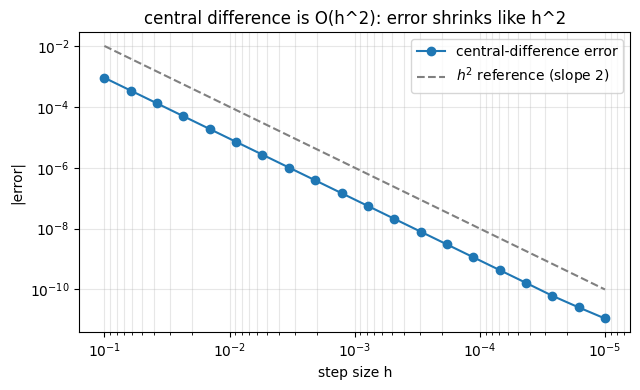

(roundoff dominates once h is tiny -- the error curve bottoms out, then worsens)


In [2]:
print("d/dx x^3 at x=2  =", nm.derivative(lambda x: x**3, 2.0), " (exact 12)")

# convergence: error vs step size h on a log-log plot -> slope 2 (second order)
hs = np.logspace(-1, -5, 20)
errs = [abs(nm.derivative(np.sin, 1.0, h) - np.cos(1.0)) for h in hs]
plt.figure(figsize=(6.5, 4))
plt.loglog(hs, errs, "o-", label="central-difference error")
plt.loglog(hs, hs**2, "--", color="gray", label="$h^2$ reference (slope 2)")
plt.gca().invert_xaxis(); plt.xlabel("step size h"); plt.ylabel("|error|")
plt.title("central difference is O(h^2): error shrinks like h^2"); plt.legend()
plt.grid(True, which="both", alpha=0.3); plt.tight_layout(); plt.show()
print("(roundoff dominates once h is tiny -- the error curve bottoms out, then worsens)")

## 2. Kinematics -- position -> velocity -> acceleration

Each step of kinematics is the **power rule applied to position**: velocity is the
first derivative, acceleration the second. A real sensor gives you a *position
track* (samples), so you differentiate numerically. For $x(t)=\tfrac12 a t^2$ the
velocity is $a t$ (a ramp) and the acceleration is the constant $a$.

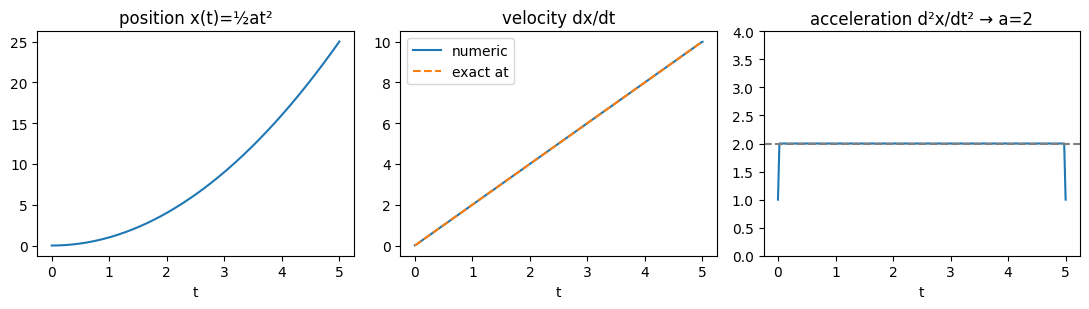

recovered constant acceleration (interior mean) = 2.0000  (exact 2)


In [3]:
t = np.linspace(0, 5, 400)
a_true = 2.0
x = 0.5 * a_true * t**2          # x = 1/2 a t^2
v = nm.velocity(x, t)            # dx/dt  -> a t
acc = nm.acceleration(x, t)      # d2x/dt2 -> a (constant)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].plot(t, x); ax[0].set_title("position x(t)=½at²"); ax[0].set_xlabel("t")
ax[1].plot(t, v, label="numeric"); ax[1].plot(t, a_true*t, "--", label="exact at")
ax[1].set_title("velocity dx/dt"); ax[1].legend(); ax[1].set_xlabel("t")
ax[2].plot(t, acc); ax[2].axhline(a_true, ls="--", color="gray")
ax[2].set_title("acceleration d²x/dt² → a=2"); ax[2].set_ylim(0, 4); ax[2].set_xlabel("t")
plt.tight_layout(); plt.show()
print(f"recovered constant acceleration (interior mean) = {acc[5:-5].mean():.4f}  (exact 2)")

## 3. Integration -- "integrals of approximation functions"

To integrate samples you fit a simple shape between them and integrate *that*:
- **trapezoid** fits a straight line between each pair of points -- error $O(h^2)$
- **Simpson** fits a parabola across each pair of intervals -- error $O(h^4)$

Same data, wildly different accuracy. $\int_0^\pi\sin x\,dx=2$ exactly.

trapezoid = 1.99983550  (error 1.6e-04, O(h^2))
Simpson   = 2.00000001  (error 1.1e-08, O(h^4) -- ~10000x better)


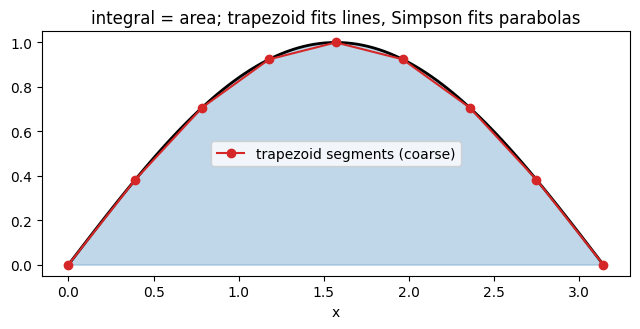

In [4]:
xs = np.linspace(0, np.pi, 101)
ys = np.sin(xs)
trap, simp = nm.trapezoid(ys, xs), nm.simpson(ys, xs)
print(f"trapezoid = {trap:.8f}  (error {abs(trap-2):.1e}, O(h^2))")
print(f"Simpson   = {simp:.8f}  (error {abs(simp-2):.1e}, O(h^4) -- ~10000x better)")

plt.figure(figsize=(6.5, 3.4))
plt.plot(xs, ys, "k", lw=2)
plt.fill_between(xs, ys, alpha=0.3, color="#2c7bb6")
xt = np.linspace(0, np.pi, 9)                     # coarse grid to SHOW the trapezoids
plt.plot(xt, np.sin(xt), "o-", color="#d62728", label="trapezoid segments (coarse)")
plt.title("integral = area; trapezoid fits lines, Simpson fits parabolas")
plt.xlabel("x"); plt.legend(); plt.tight_layout(); plt.show()

## 4. The Fundamental Theorem, numerically

The **cumulative integral** $F(x)=\int_{x_0}^x y\,dt$ and the derivative are
inverses. Integrate $\cos$ to get $\sin$, then differentiate back to $\cos$ -- the
numerical round-trip of the Fundamental Theorem of Calculus.

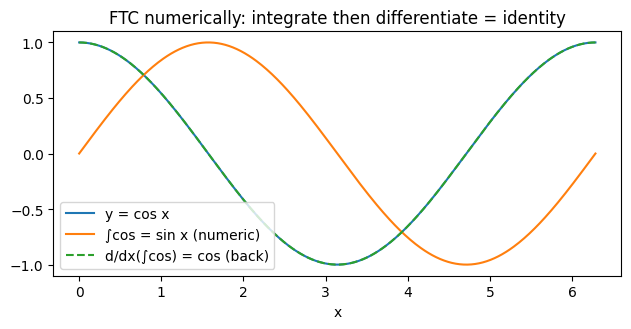

max round-trip error: 6.199141038965017e-05


In [5]:
xs = np.linspace(0, 2*np.pi, 400)
F = nm.cumulative_integral(np.cos(xs), xs)        # integral of cos = sin
back = nm.gradient(F, xs)                          # d/dx of that = cos again
plt.figure(figsize=(6.5, 3.4))
plt.plot(xs, np.cos(xs), label="y = cos x")
plt.plot(xs, F, label="∫cos = sin x (numeric)")
plt.plot(xs, back, "--", label="d/dx(∫cos) = cos (back)")
plt.legend(); plt.title("FTC numerically: integrate then differentiate = identity")
plt.xlabel("x"); plt.tight_layout(); plt.show()
print("max round-trip error:", np.max(np.abs(back[2:-2] - np.cos(xs)[2:-2])))

## 5. Taylor approximation from numerical derivatives (series)

A Taylor polynomial is a local model built from the derivatives at a point. Here
the derivatives are taken *numerically*, and we watch higher orders hug $e^x$ over
a wider range -- the **series** as a design tool for cheap local approximation.

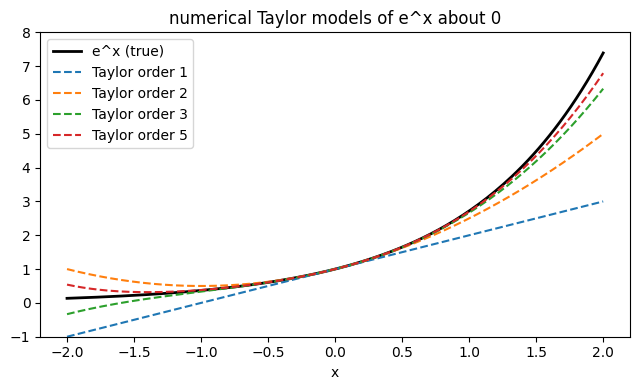

e^0.5: order-5 Taylor = 1.6482351002205327  exact = 1.6487212707001282


In [6]:
xg = np.linspace(-2, 2, 200)
plt.figure(figsize=(6.5, 4))
plt.plot(xg, np.exp(xg), "k", lw=2, label="e^x (true)")
for order in (1, 2, 3, 5):
    plt.plot(xg, nm.taylor_approx(np.exp, 0.0, order, xg), "--",
             label=f"Taylor order {order}")
plt.ylim(-1, 8); plt.legend(); plt.title("numerical Taylor models of e^x about 0")
plt.xlabel("x"); plt.tight_layout(); plt.show()
print("e^0.5: order-5 Taylor =", nm.taylor_approx(np.exp, 0.0, 5, 0.5),
      " exact =", np.exp(0.5))

## 6. Griffiths' flux rule, verified numerically (Fig 7.13)

The motional-emf proof: a rectangular loop (height $h$) in field $B$ with its edge
at $x(t)$ has flux $\Phi=Bhx$. The flux rule says
$\varepsilon=-\dfrac{d\Phi}{dt}$. For a loop pulled at speed $v$ (so
$x(t)=x_0-vt$), $\dfrac{d\Phi}{dt}=-Bhv$ and the emf is $+Bhv$. We compute
$d\Phi/dt$ **numerically from the position track** -- no formula -- and recover it.

dPhi/dt (numeric) = -3.0000   -B h v = -3.0000
emf = -dPhi/dt    = 3.0000   +B h v = 3.0000  (Griffiths 7.13)


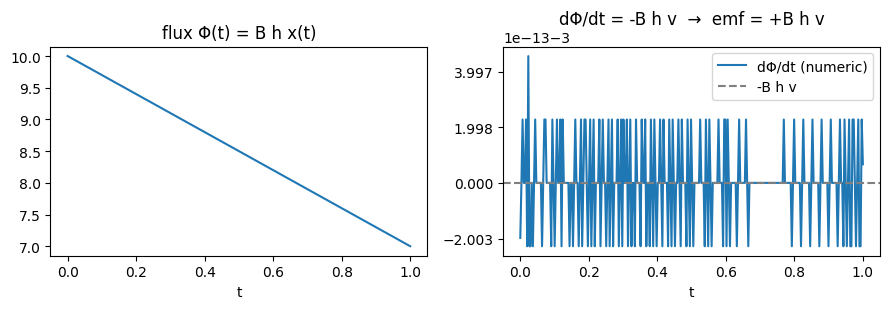

In [7]:
B, h, v0, x0 = 0.5, 2.0, 3.0, 10.0
t = np.linspace(0, 1, 300)
x_t = x0 - v0 * t                       # loop edge sliding in at speed v0
Phi = B * h * x_t
dPhi = nm.motional_flux_rate(B, h, x_t, t)
print(f"dPhi/dt (numeric) = {dPhi.mean():.4f}   -B h v = {-B*h*v0:.4f}")
print(f"emf = -dPhi/dt    = {-dPhi.mean():.4f}   +B h v = {B*h*v0:.4f}  (Griffiths 7.13)")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(t, Phi); ax[0].set_title("flux Φ(t) = B h x(t)"); ax[0].set_xlabel("t")
ax[1].plot(t, dPhi, label="dΦ/dt (numeric)")
ax[1].axhline(-B*h*v0, ls="--", color="gray", label="-B h v")
ax[1].set_title("dΦ/dt = -B h v  →  emf = +B h v"); ax[1].legend(); ax[1].set_xlabel("t")
plt.tight_layout(); plt.show()

## What you can design with this

| numerical tool | error order | what it becomes |
|---|---|---|
| central difference | $O(h^2)$ | velocity/acceleration from a position track; $\beta_2=d^2\beta/d\omega^2$ |
| trapezoid | $O(h^2)$ | quick area/energy/charge from samples |
| Simpson | $O(h^4)$ | accurate quadrature when the signal is smooth |
| cumulative integral | -- | the FTC: integrate a rate to get the total |
| numerical Taylor | -- | cheap local polynomial models (series) |
| `motional_flux_rate` | $O(h^2)$ | emf $=-d\Phi/dt$ straight from measured flux |

Symbolic calculus proves the rule; **numerical calculus runs it on real data**.
That is the half you build instruments and solvers out of. Civilian education.